In [2]:
import copy
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split

In [3]:
def show_predictions(model, X, y):

    y_predict = model(torch.tensor(X, dtype=torch.float32))
    y_predict = y_predict.detach().numpy()
    plt.plot(y, y_predict, '.')
    plt.xlabel('Tc real')
    plt.ylabel('Tc predicted')
    plt.show()

In [4]:
def dataframe_to_sklearn_dataset(df):
    """
    Convert a pandas DataFrame into an sklearn-style regression dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with x columns:
        - first x-1 columns are features
        - last column is the target

    Returns
    -------
    dict
        sklearn-style dataset dictionary
    """

    feature_names = df.columns[:-1].tolist()
    target_name = df.columns[-1]

    data = df.iloc[:, :-1].to_numpy(dtype=float)
    target = df.iloc[:, -1].to_numpy(dtype=float)

    dataset = {
        "data": data,
        "target": target,
        "frame": None,
        "target_names": [target_name],
        "feature_names": feature_names,
    }

    return dataset

In [22]:
data = pd.read_csv(r'C:\Users\amyry\OneDrive - University of Cambridge\NanoDTC_\Coding\pml_supercond\data\raw\train.csv')
data.head()
data.columns

Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

In [23]:
filtered_params=['range_ThermalConductivity', 'wtd_std_ThermalConductivity', 'range_atomic_radius', 'wtd_gmean_ThermalConductivity','std_ThermalConductivity','wtd_entropy_Valence','wtd_std_ElectronAffinity','wtd_entropy_atomic_mass']
data_filtered = data.filter(items=(filtered_params + ['critical_temp']))
data_filtered.head()

,range_ThermalConductivity,wtd_std_ThermalConductivity,range_atomic_radius,wtd_gmean_ThermalConductivity,std_ThermalConductivity,wtd_entropy_Valence,wtd_std_ElectronAffinity,wtd_entropy_atomic_mass,critical_temp
0,399.97342,138.517163,205,0.621979,168.854244,1.066221,42.558396,1.062396,29.0
1,429.97342,139.630922,205,0.619735,198.554600,1.047221,41.667621,1.057755,26.0
2,399.97342,138.540613,205,0.619095,168.854244,1.029175,41.639878,0.975980,19.0
3,399.97342,138.528893,205,0.620535,168.854244,1.048834,42.102344,1.022291,22.0
4,399.97342,138.493671,205,0.624878,168.854244,1.096052,43.452059,1.129224,23.0


In [24]:
data_sk = dataframe_to_sklearn_dataset(data_filtered)
print(data_sk)

{'data': array([[399.97342   , 138.51716251, 205.        , ...,   1.06622103,
         42.55839575,   1.06239555],
       [429.97342   , 139.63092237, 205.        , ...,   1.04722137,
         41.6676208 ,   1.05775512],
       [399.97342   , 138.54061274, 205.        , ...,   1.02917469,
         41.6398778 ,   0.97598046],
       ...,
       [ 17.        ,   6.8       ,  29.        , ...,   0.45056121,
         12.96      ,   0.53019754],
       [ 17.        ,   7.86238513,  29.        , ...,   0.57760119,
         14.98478108,   0.64088299],
       [ 78.48      ,  38.25443159,  53.        , ...,   0.97011578,
         87.74050433,   0.89522916]], shape=(21263, 8)), 'target': array([29.  , 26.  , 19.  , ...,  1.98,  1.84, 12.8 ], shape=(21263,)), 'frame': None, 'target_names': ['critical_temp'], 'feature_names': ['range_ThermalConductivity', 'wtd_std_ThermalConductivity', 'range_atomic_radius', 'wtd_gmean_ThermalConductivity', 'std_ThermalConductivity', 'wtd_entropy_Valence', 'wtd_st

In [28]:
# Read data
X, y = data_sk['data'], data_sk['target']

# Apply normalisation
X_norm = X / X.max(axis=0)
y_max = y.max()
y_norm = y / y_max
print(y_max)


# train-test split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, train_size=0.7, shuffle=True)
print(f"Filtered Train Shape: {X_train.shape}") 
print(f"Filtered Test Shape: {X_test.shape}")

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


185.0
Filtered Train Shape: (14884, 8)
Filtered Test Shape: (6379, 8)


In [32]:
# Define the model. 8 input parameters
model = nn.Sequential(
    nn.Linear(8, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

Learning rate: 0.0001
Epoch 0: MSE = 0.0143 scaled: 490.03
Epoch 1: MSE = 0.0129 scaled: 443.14
Epoch 2: MSE = 0.0123 scaled: 421.77
Epoch 3: MSE = 0.0119 scaled: 408.16
Epoch 4: MSE = 0.0116 scaled: 395.88
Epoch 5: MSE = 0.0113 scaled: 385.89
Epoch 6: MSE = 0.0110 scaled: 376.07
Epoch 7: MSE = 0.0107 scaled: 367.78
Epoch 8: MSE = 0.0105 scaled: 360.20
Epoch 9: MSE = 0.0103 scaled: 353.73
Epoch 10: MSE = 0.0101 scaled: 346.65
Epoch 11: MSE = 0.0100 scaled: 340.56
Epoch 12: MSE = 0.0098 scaled: 335.21
Epoch 13: MSE = 0.0096 scaled: 330.16
Epoch 14: MSE = 0.0095 scaled: 326.05
Epoch 15: MSE = 0.0094 scaled: 322.00
Epoch 16: MSE = 0.0093 scaled: 318.25
Epoch 17: MSE = 0.0092 scaled: 314.98
Epoch 18: MSE = 0.0091 scaled: 311.91
Epoch 19: MSE = 0.0091 scaled: 309.81
Epoch 20: MSE = 0.0089 scaled: 306.12
Epoch 21: MSE = 0.0089 scaled: 303.96
Epoch 22: MSE = 0.0088 scaled: 301.00
Epoch 23: MSE = 0.0087 scaled: 298.93
Epoch 24: MSE = 0.0087 scaled: 297.83
Epoch 25: MSE = 0.0087 scaled: 296.40


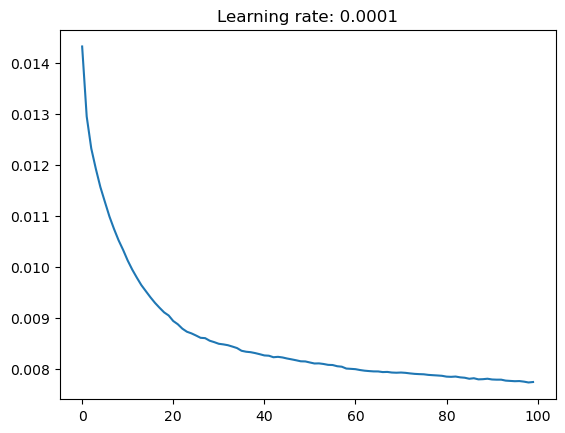

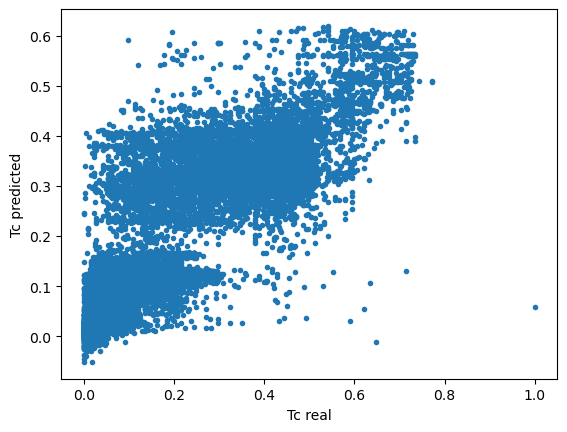

Learning rate: 0.001
Epoch 0: MSE = 0.0119 scaled: 407.14
Epoch 1: MSE = 0.0109 scaled: 371.74
Epoch 2: MSE = 0.0100 scaled: 341.73
Epoch 3: MSE = 0.0091 scaled: 312.51
Epoch 4: MSE = 0.0089 scaled: 305.53
Epoch 5: MSE = 0.0089 scaled: 304.66
Epoch 6: MSE = 0.0086 scaled: 292.74
Epoch 7: MSE = 0.0086 scaled: 293.52
Epoch 8: MSE = 0.0083 scaled: 285.54
Epoch 9: MSE = 0.0083 scaled: 282.82
Epoch 10: MSE = 0.0082 scaled: 279.23
Epoch 11: MSE = 0.0081 scaled: 276.68
Epoch 12: MSE = 0.0080 scaled: 274.61
Epoch 13: MSE = 0.0080 scaled: 274.29
Epoch 14: MSE = 0.0080 scaled: 272.21
Epoch 15: MSE = 0.0080 scaled: 273.69
Epoch 16: MSE = 0.0080 scaled: 272.82
Epoch 17: MSE = 0.0080 scaled: 272.66
Epoch 18: MSE = 0.0079 scaled: 271.42
Epoch 19: MSE = 0.0081 scaled: 276.42
Epoch 20: MSE = 0.0081 scaled: 277.23
Epoch 21: MSE = 0.0080 scaled: 272.69
Epoch 22: MSE = 0.0081 scaled: 276.67
Epoch 23: MSE = 0.0081 scaled: 277.03
Epoch 24: MSE = 0.0082 scaled: 279.66
Epoch 25: MSE = 0.0080 scaled: 274.40
E

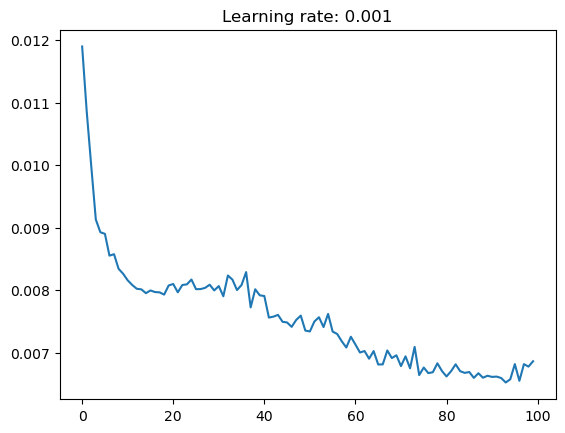

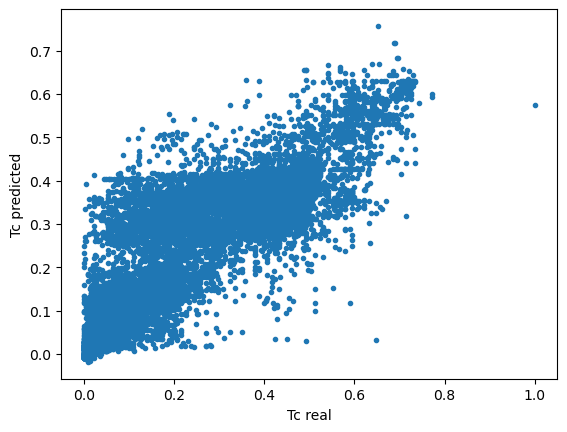

Learning rate: 0.01
Epoch 0: MSE = 0.0127 scaled: 433.49
Epoch 1: MSE = 0.0144 scaled: 492.84
Epoch 2: MSE = 0.0107 scaled: 367.18
Epoch 3: MSE = 0.0131 scaled: 448.83
Epoch 4: MSE = 0.0111 scaled: 380.89
Epoch 5: MSE = 0.0103 scaled: 353.90
Epoch 6: MSE = 0.0110 scaled: 377.83
Epoch 7: MSE = 0.0112 scaled: 383.73
Epoch 8: MSE = 0.0098 scaled: 336.81
Epoch 9: MSE = 0.0090 scaled: 307.18
Epoch 10: MSE = 0.0094 scaled: 321.34
Epoch 11: MSE = 0.0096 scaled: 329.75
Epoch 12: MSE = 0.0092 scaled: 316.10
Epoch 13: MSE = 0.0091 scaled: 310.17
Epoch 14: MSE = 0.0092 scaled: 314.28
Epoch 15: MSE = 0.0090 scaled: 308.86
Epoch 16: MSE = 0.0087 scaled: 298.90
Epoch 17: MSE = 0.0088 scaled: 301.20
Epoch 18: MSE = 0.0088 scaled: 300.44
Epoch 19: MSE = 0.0086 scaled: 292.99
Epoch 20: MSE = 0.0087 scaled: 296.74
Epoch 21: MSE = 0.0086 scaled: 295.39
Epoch 22: MSE = 0.0088 scaled: 300.38
Epoch 23: MSE = 0.0086 scaled: 295.77
Epoch 24: MSE = 0.0101 scaled: 345.97
Epoch 25: MSE = 0.0088 scaled: 300.80
Ep

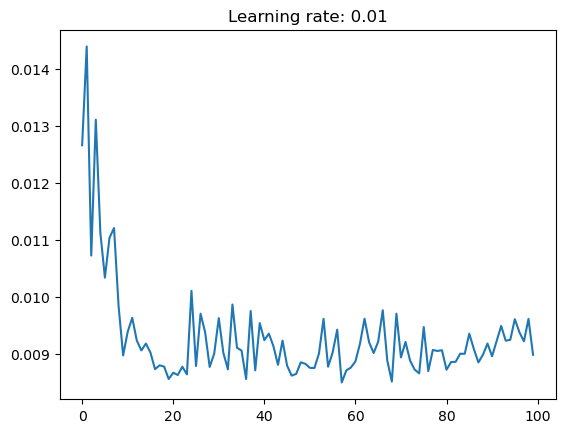

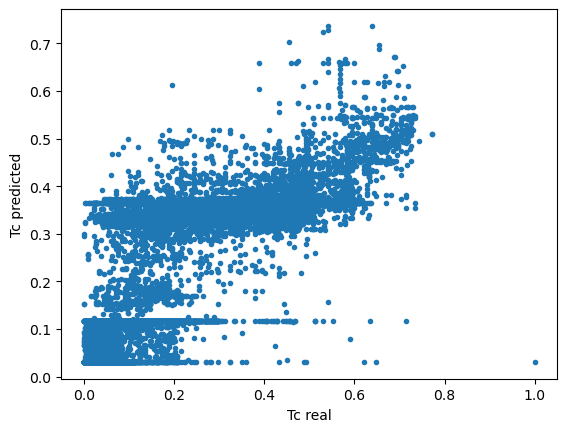

In [34]:
def train(lr):
    model = nn.Sequential(
        nn.Linear(8, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, 1)
    )
    # loss function and optimizer
    loss_fn = nn.MSELoss()  # mean square error
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    n_epochs = 100   # number of epochs to run
    batch_size = 10  # size of each batch
    batch_start = torch.arange(0, len(X_train), batch_size)
    
    # Hold the best model
    best_mse = np.inf   # init to infinity
    best_weights = None
    history = []
    
    for epoch in range(n_epochs):
        model.train()
        with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
            bar.set_description(f"Epoch {epoch}")
            for start in bar:
                # take a batch
                X_batch = X_train[start:start+batch_size]
                y_batch = y_train[start:start+batch_size]
                # forward pass
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)
                # backward pass
                optimizer.zero_grad()
                loss.backward()
                # update weights
                optimizer.step()
                # print progress
                bar.set_postfix(mse=float(loss))
        # evaluate accuracy at end of each epoch
        model.eval()
        y_pred = model(X_test)
        mse = loss_fn(y_pred, y_test)
        mse = float(mse)
        history.append(mse)
        if mse < best_mse:
            best_mse = mse
            best_weights = copy.deepcopy(model.state_dict())
        print(f"Epoch {epoch}: MSE = {mse:.4f}", "scaled: %.2f" % (mse * y_max**2))
    
    # restore model and return best accuracy
    model.load_state_dict(best_weights)
    print("MSE: %.4f " % best_mse, "scaled: %.2f" % (best_mse * y_max**2))
    print("RMSE: %.4f " % np.sqrt(best_mse), "scaled: %.2f" % (np.sqrt(best_mse) * y_max))
    plt.plot(history)
    plt.title(f"Learning rate: {lr}")
    plt.show()
    show_predictions(model, X_norm, y_norm)

for lr in [0.0001, 0.001, 0.01]:
    print(f"Learning rate: {lr}")
    train(lr)

Learning rate: 0.0001
Epoch 0: MSE = 0.0138 scaled: 471.68
Epoch 1: MSE = 0.0124 scaled: 422.86
Epoch 2: MSE = 0.0118 scaled: 404.96
Epoch 3: MSE = 0.0116 scaled: 397.58
Epoch 4: MSE = 0.0114 scaled: 389.71
Epoch 5: MSE = 0.0112 scaled: 383.71
Epoch 6: MSE = 0.0111 scaled: 378.56
Epoch 7: MSE = 0.0108 scaled: 370.71
Epoch 8: MSE = 0.0106 scaled: 364.22
Epoch 9: MSE = 0.0105 scaled: 358.24
Epoch 10: MSE = 0.0103 scaled: 351.42
Epoch 11: MSE = 0.0100 scaled: 343.11
Epoch 12: MSE = 0.0098 scaled: 336.94
Epoch 13: MSE = 0.0097 scaled: 330.47
Epoch 14: MSE = 0.0095 scaled: 324.90
Epoch 15: MSE = 0.0093 scaled: 319.68
Epoch 16: MSE = 0.0092 scaled: 315.35
Epoch 17: MSE = 0.0091 scaled: 311.70
Epoch 18: MSE = 0.0090 scaled: 308.14
Epoch 19: MSE = 0.0089 scaled: 304.97
Epoch 20: MSE = 0.0088 scaled: 302.78
Epoch 21: MSE = 0.0088 scaled: 300.52
Epoch 22: MSE = 0.0087 scaled: 297.66
Epoch 23: MSE = 0.0086 scaled: 295.89
Epoch 24: MSE = 0.0086 scaled: 294.00
Epoch 25: MSE = 0.0086 scaled: 293.30


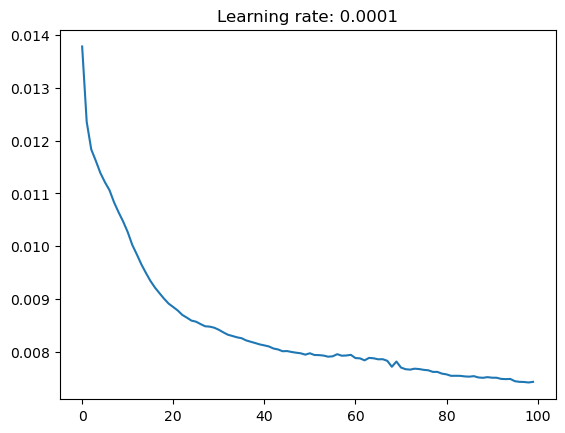

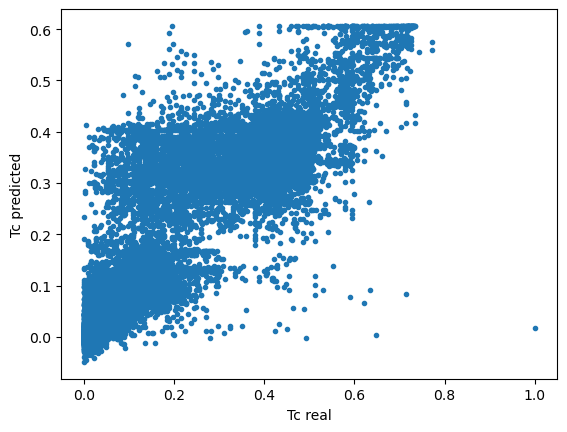

Learning rate: 0.0002
Epoch 0: MSE = 0.0127 scaled: 433.89
Epoch 1: MSE = 0.0118 scaled: 402.63
Epoch 2: MSE = 0.0114 scaled: 390.62
Epoch 3: MSE = 0.0112 scaled: 384.47
Epoch 4: MSE = 0.0110 scaled: 375.66
Epoch 5: MSE = 0.0107 scaled: 367.60
Epoch 6: MSE = 0.0105 scaled: 360.44
Epoch 7: MSE = 0.0104 scaled: 354.73
Epoch 8: MSE = 0.0101 scaled: 347.36
Epoch 9: MSE = 0.0099 scaled: 339.67
Epoch 10: MSE = 0.0097 scaled: 331.12
Epoch 11: MSE = 0.0095 scaled: 325.19
Epoch 12: MSE = 0.0093 scaled: 318.79
Epoch 13: MSE = 0.0092 scaled: 313.19
Epoch 14: MSE = 0.0090 scaled: 307.74
Epoch 15: MSE = 0.0088 scaled: 301.99
Epoch 16: MSE = 0.0087 scaled: 298.01
Epoch 17: MSE = 0.0086 scaled: 294.74
Epoch 18: MSE = 0.0086 scaled: 292.71
Epoch 19: MSE = 0.0085 scaled: 290.07
Epoch 20: MSE = 0.0084 scaled: 287.94
Epoch 21: MSE = 0.0084 scaled: 286.64
Epoch 22: MSE = 0.0083 scaled: 283.98
Epoch 23: MSE = 0.0083 scaled: 283.35
Epoch 24: MSE = 0.0082 scaled: 281.53
Epoch 25: MSE = 0.0082 scaled: 280.26


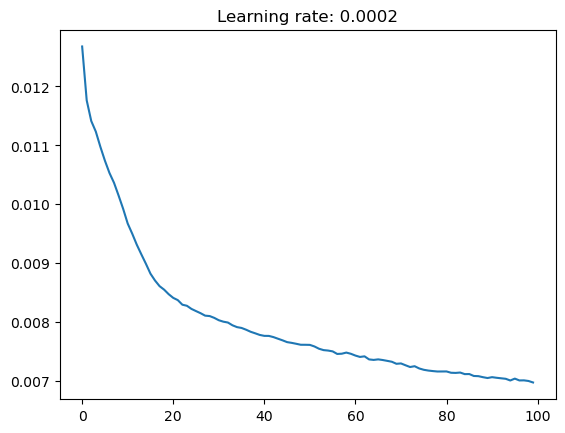

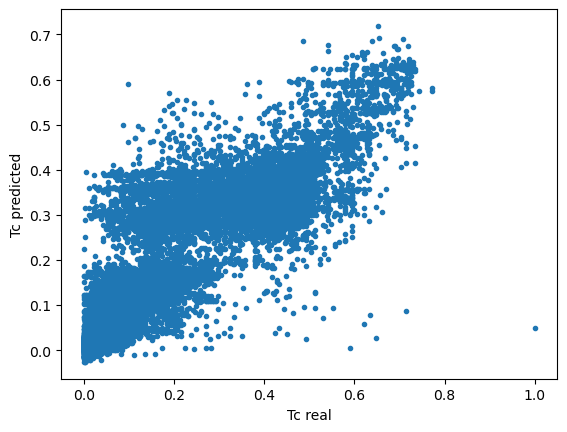

Learning rate: 0.0005
Epoch 0: MSE = 0.0117 scaled: 401.50
Epoch 1: MSE = 0.0108 scaled: 369.62
Epoch 2: MSE = 0.0102 scaled: 349.47
Epoch 3: MSE = 0.0095 scaled: 325.19
Epoch 4: MSE = 0.0090 scaled: 309.58
Epoch 5: MSE = 0.0086 scaled: 294.92
Epoch 6: MSE = 0.0084 scaled: 287.88
Epoch 7: MSE = 0.0083 scaled: 283.76
Epoch 8: MSE = 0.0082 scaled: 281.28
Epoch 9: MSE = 0.0081 scaled: 277.23
Epoch 10: MSE = 0.0081 scaled: 278.39
Epoch 11: MSE = 0.0081 scaled: 276.27
Epoch 12: MSE = 0.0081 scaled: 276.80
Epoch 13: MSE = 0.0080 scaled: 275.03
Epoch 14: MSE = 0.0081 scaled: 277.08
Epoch 15: MSE = 0.0080 scaled: 273.03
Epoch 16: MSE = 0.0081 scaled: 275.74
Epoch 17: MSE = 0.0080 scaled: 272.90
Epoch 18: MSE = 0.0079 scaled: 270.37
Epoch 19: MSE = 0.0078 scaled: 266.42
Epoch 20: MSE = 0.0079 scaled: 268.73
Epoch 21: MSE = 0.0077 scaled: 263.72
Epoch 22: MSE = 0.0077 scaled: 262.98
Epoch 23: MSE = 0.0076 scaled: 258.73
Epoch 24: MSE = 0.0077 scaled: 263.05
Epoch 25: MSE = 0.0076 scaled: 260.26


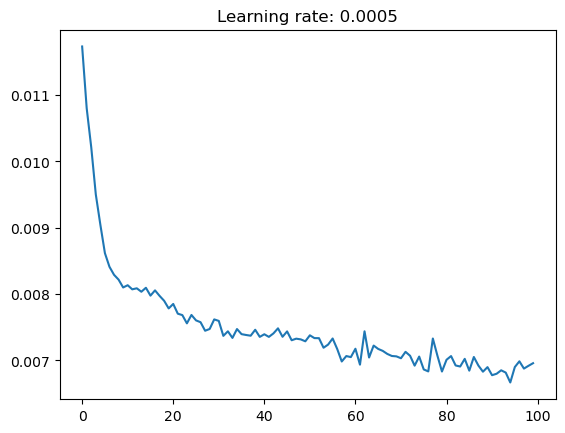

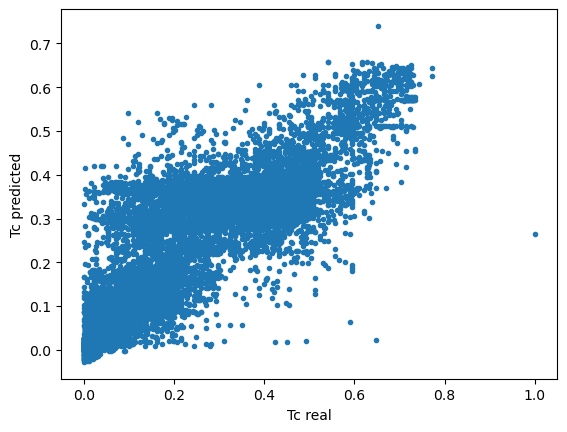

Learning rate: 0.0007
Epoch 0: MSE = 0.0122 scaled: 416.70
Epoch 1: MSE = 0.0109 scaled: 372.51
Epoch 2: MSE = 0.0102 scaled: 350.78
Epoch 3: MSE = 0.0096 scaled: 327.17
Epoch 4: MSE = 0.0090 scaled: 309.40
Epoch 5: MSE = 0.0088 scaled: 299.53
Epoch 6: MSE = 0.0085 scaled: 292.21
Epoch 7: MSE = 0.0084 scaled: 287.71
Epoch 8: MSE = 0.0083 scaled: 285.00
Epoch 9: MSE = 0.0082 scaled: 281.69
Epoch 10: MSE = 0.0082 scaled: 280.26
Epoch 11: MSE = 0.0081 scaled: 277.26
Epoch 12: MSE = 0.0081 scaled: 276.08
Epoch 13: MSE = 0.0080 scaled: 274.36
Epoch 14: MSE = 0.0079 scaled: 271.45
Epoch 15: MSE = 0.0080 scaled: 272.27
Epoch 16: MSE = 0.0079 scaled: 270.99
Epoch 17: MSE = 0.0079 scaled: 269.12
Epoch 18: MSE = 0.0079 scaled: 268.99
Epoch 19: MSE = 0.0078 scaled: 267.04
Epoch 20: MSE = 0.0078 scaled: 267.21
Epoch 21: MSE = 0.0078 scaled: 265.48
Epoch 22: MSE = 0.0078 scaled: 266.02
Epoch 23: MSE = 0.0077 scaled: 262.35
Epoch 24: MSE = 0.0077 scaled: 262.28
Epoch 25: MSE = 0.0075 scaled: 257.75


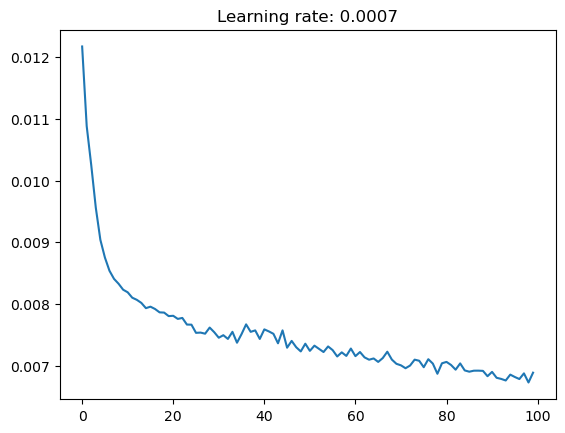

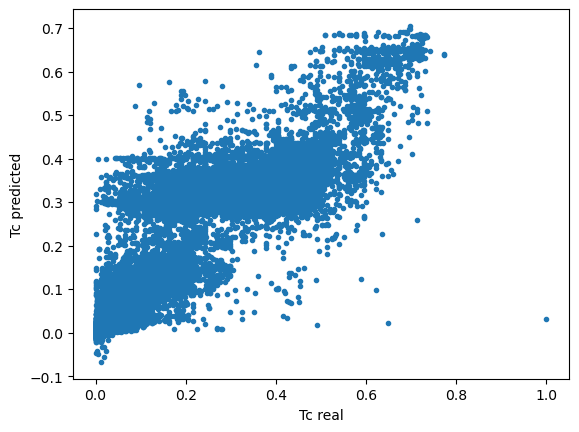

In [35]:
for lr in [0.0001, 0.0002, 0.0005, 0.0007]:
    print(f"Learning rate: {lr}")
    train(lr)